<a href="https://colab.research.google.com/github/sruthi-analyst/sruthi-codeboosters-2026/blob/main/Day5/MiniFinal_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT-2: Weather Intelligence System

1.   weather data
2.   data engineering
3. visualisation
4. Training
5. Validating




In [1]:
import requests
import gzip
import json
import os

import numpy as np
import pandas as pd

import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



[1] loaddata from Open Weathers API key


In [3]:
API_KEY = '84f9cb655f58c2e1901feba8466c1384'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather?'
# CITIES = ['Coimbatore', 'Delhi', 'Chennai', 'Jolarpet', 'Pollachi',
#           'Tirunelveli', 'Jaipur', 'Kolkata', 'Pune', 'Bangalore']

print(f'API configured for fetching cities')
# print(f'Cities: {CITIES}')

API configured for fetching cities


### Download and Extract City Data from `.gz` File

To get a broader list of cities, we can download a compressed city list (e.g., `city.list.json.gz` from OpenWeatherMap) and extract city names from it. This allows us to use more than just the manually defined `CITIES` list.

[2] Get the list of 500 cities' ID or Names and store as a list

In [4]:
# Define the URL for the city list (OpenWeatherMap example)
city_list_url = 'http://bulk.openweathermap.org/sample/city.list.json.gz'
compressed_filename = 'city.list.json.gz'
decompressed_filename = 'city.list.json'

print(f"Attempting to download city list from: {city_list_url}")

# Download the compressed file
try:
    response = requests.get(city_list_url, stream=True)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    with open(compressed_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Downloaded {compressed_filename}")

    # Decompress the file
    with gzip.open(compressed_filename, 'rb') as f_in:
        with open(decompressed_filename, 'wb') as f_out:
            f_out.write(f_in.read())
    print(f"Decompressed to {decompressed_filename}")

    # Load and process the JSON data
    with open(decompressed_filename, 'r', encoding='utf-8') as f:
        city_data = json.load(f)
    print("Loaded city data.")

    # Extract city names and update the CITIES list
    # We'll take the first 500 cities that have a 'name' field.
    new_cities = []
    for city_entry in city_data:
        if 'name' in city_entry:
            new_cities.append(city_entry['name'])
        if len(new_cities) >= 500:
            break

    global CITIES # Declare CITIES as global to modify the existing list
    CITIES = new_cities

    print(f'Updated CITIES list with {len(CITIES)} cities from the .gz file.')
    print(f'First 5 cities: {CITIES[:5]}')
    print(f'Last 5 cities: {CITIES[-5:]}')

except requests.exceptions.RequestException as e:
    print(f"Error downloading or processing file: {e}")
    print("Could not retrieve city list from OpenWeatherMap. Using the predefined CITIES list.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    print("Using the predefined CITIES list.")
finally:
    # Clean up downloaded files (optional)
    if os.path.exists(compressed_filename):
        os.remove(compressed_filename)
    if os.path.exists(decompressed_filename):
        os.remove(decompressed_filename)
    print("Cleaned up temporary files.")

Attempting to download city list from: http://bulk.openweathermap.org/sample/city.list.json.gz
Downloaded city.list.json.gz
Decompressed to city.list.json
Loaded city data.
Updated CITIES list with 500 cities from the .gz file.
First 5 cities: ['Ḩeşār-e Sefīd', '‘Ayn Ḩalāqīm', 'Taglag', 'Qabāghlū', '‘Arīqah']
Last 5 cities: ['Tārūt', 'Tanūmah', 'Tamrah', 'Minţaqat Tabūk', 'Tabuk']
Cleaned up temporary files.


[3] Get a data set of weather attributes for 500 cities and save it in a list
e.g.: Saacow

In [5]:
def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,            # City name query parameter
      'appid': api_key,     # Authentication key
      'units': 'metric'     # Returns temperature in Celcius
  }
  # params in a dictionary - requests will encode it into the URL: ?q=Mumbai&appid=KEY&units=metric

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)
    #requests.get() sends an HTTP GET request to BASE URL
    #timeout=10 waits max for 10 seconds; raise error if no response

    if response.status_code==200:
      #statuc_code 200 = HTTP OK = request was successful
      data = response.json()
      # .json parses the JSON text body into a Python dictionary

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0) #.get('visibility', 0) is safe access: return 0 if key is missing,
          #1000 - convert meters to kilimeters (integer division)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  # print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    # print(f'{record['temperature']}°C', {record['condition']})
    # print('\n', record)
  # else:
    # print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...

Successfully fetched: 500/500 cities


[4] Store the loaded data into a DataFrame

In [6]:
weather_df = pd.DataFrame(weather_records)
print(weather_df.to_string(index=False))

print("\nShape of weather_df: ", weather_df.shape)
print(f"Missing Values : {weather_df.isnull().sum().sum()}")
print("\nData types: \n",weather_df.dtypes)

                       city  temperature  feels_like  humidity  pressure  wind_speed               condition  visibility
              Ḩeşār-e Sefīd         19.0        17.9        37      1014        5.14               Clear Sky       10000
               ‘Ayn Ḩalāqīm         13.6        13.3        87      1014        2.61               Clear Sky       10000
                     Taglag         15.1        14.2        58      1010        1.62               Clear Sky       10000
                   Qabāghlū         12.2        11.1        62      1014        2.86               Clear Sky       10000
                    ‘Arīqah         17.8        17.4        68      1014        5.43               Clear Sky       10000
          Kalāteh-ye Dowlat         32.1        30.1        20      1003        4.87         Overcast Clouds       10000
                 Behjatābād         19.0        19.4        94      1015        1.03              Light Rain        5000
            Ţālesh Maḩalleh     

[5] Clean the DataFrame

In [7]:
print(f"No. of missing values: {weather_df.isnull().sum().sum()}\nNo. of duplicates: {weather_df.duplicated().sum()}")
print("Before handling duplicates:\t", weather_df.duplicated().sum(), "duplicate rows")
weather_df.drop_duplicates(inplace=True)
print("After handling duplicates:\t", weather_df.duplicated().sum(), "duplicate rows")
print("DATA SET CLEANED SUCCESSFULLY (●'◡'●)")

No. of missing values: 0
No. of duplicates: 7
Before handling duplicates:	 7 duplicate rows
After handling duplicates:	 0 duplicate rows
DATA SET CLEANED SUCCESSFULLY (●'◡'●)


[6] Save the cleaned data into cleaned_weather.csv file

In [8]:
weather_df.to_csv('cleaned_weather.csv', index=False)
print("CLEANED DATA SAVED INTO 'cleaned_weather.csv' ")

CLEANED DATA SAVED INTO 'cleaned_weather.csv' 


[7] Load the data to DataBase

In [22]:
conn = sqlite3.connect('Weather.db')
cursor = conn.cursor()
weather_df.to_sql(
    'weather',     #Name of table to creare in the database
    conn,           #Which db connection object to use
    if_exists = 'replace', #Is 'students' tab;e exists, replace it
    index=False     #Do not write DataFrame row numbes as a column
)
cursor.execute("SELECT COUNT(*) FROM weather")

count = cursor.fetchone()[0]
print("Database 'weather.db' created successfully!")
print(f"Table weathers has {count} rows")


Database 'weather.db' created successfully!
Table weathers has 493 rows


In [23]:
# Fetch all data from the 'weather' table
sql_query_all = "SELECT * FROM weather"
weather_data_from_db = pd.read_sql_query(sql_query_all, conn)

print("Data fetched from 'Weather.db' successfully:")
display(weather_data_from_db.head())

Data fetched from 'Weather.db' successfully:


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Ḩeşār-e Sefīd,19.0,17.9,37,1014,5.14,Clear Sky,10000
1,‘Ayn Ḩalāqīm,13.6,13.3,87,1014,2.61,Clear Sky,10000
2,Taglag,15.1,14.2,58,1010,1.62,Clear Sky,10000
3,Qabāghlū,12.2,11.1,62,1014,2.86,Clear Sky,10000
4,‘Arīqah,17.8,17.4,68,1014,5.43,Clear Sky,10000


### Line Graph: Temperature Across Cities

Let's visualize the temperature for a selection of cities to see the variation. We'll sort by city name for better readability.

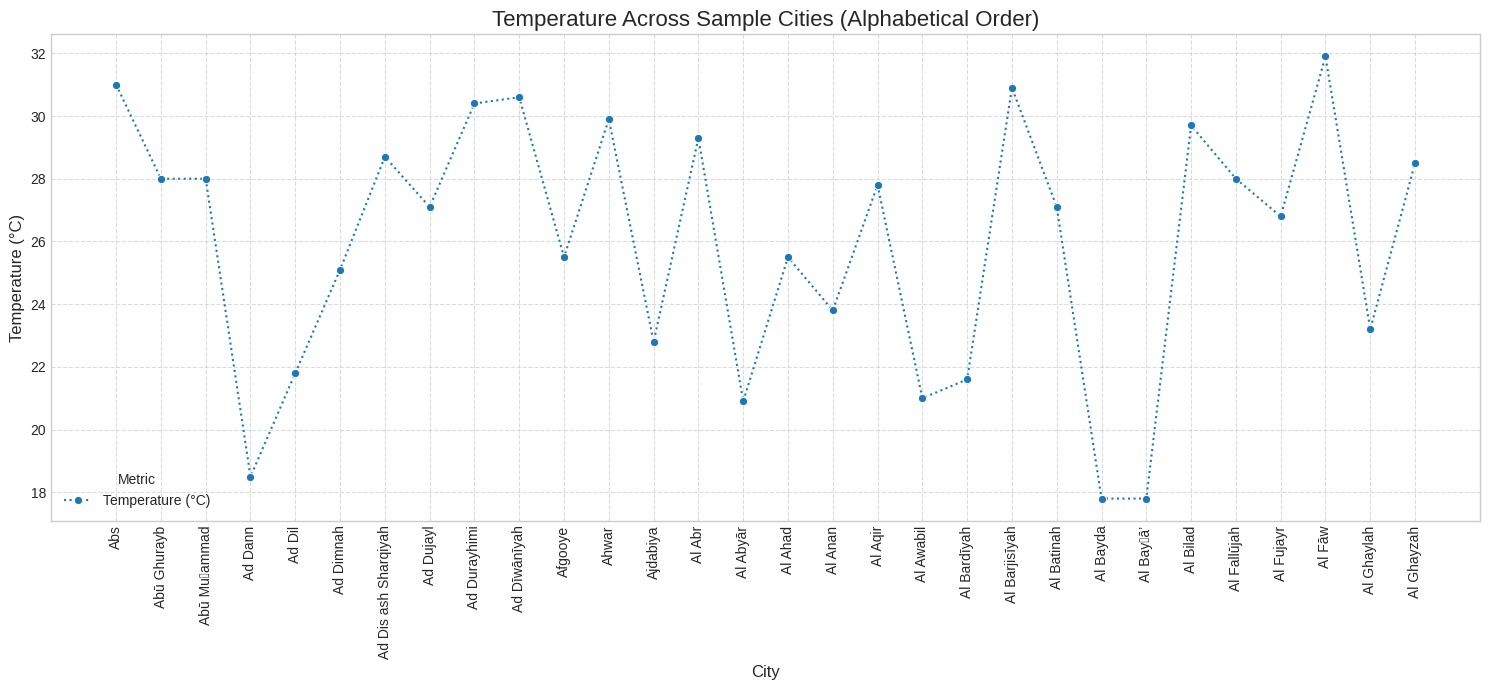

In [24]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
sns.lineplot(x='city', y='temperature', data=weather_data_from_db.sort_values('city').head(30), marker='o', linestyle=':', label='Temperature (°C)', palette='crest') # Changed linestyle to dotted and added label for legend
plt.title('Temperature Across Sample Cities (Alphabetical Order)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Metric') # Added legend
plt.tight_layout()
plt.show()

### Horizontal Bar Chart: Top 10 Cities by Wind Speed

Now, let's look at the cities with the highest wind speeds using a horizontal bar chart.

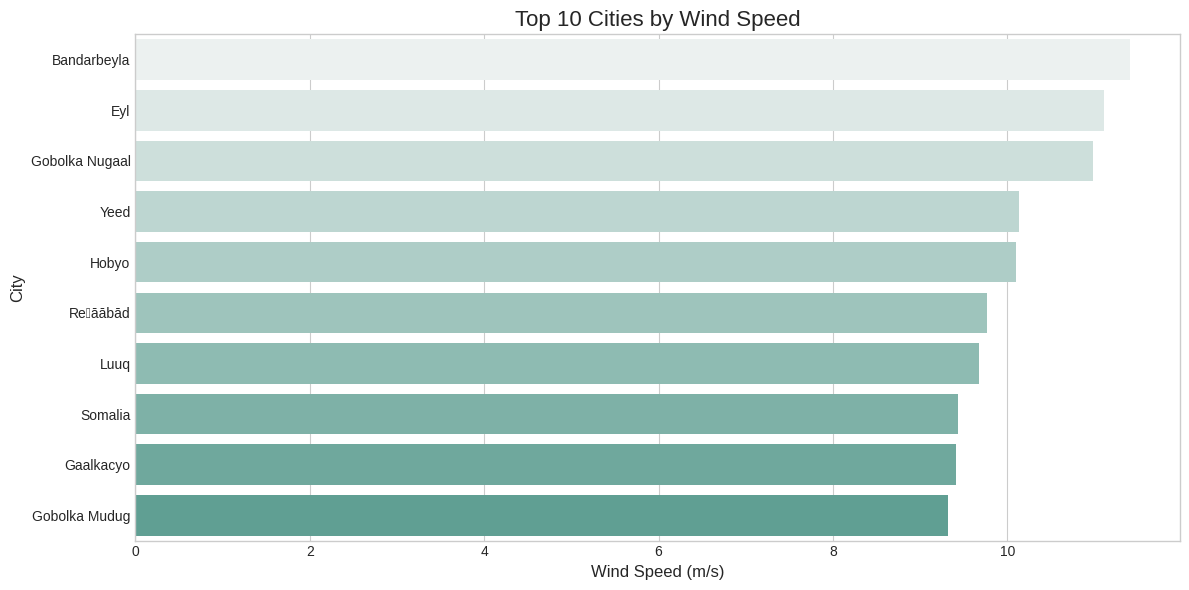

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
top_wind_cities = weather_data_from_db.nlargest(10, 'wind_speed')

plt.figure(figsize=(12, 6))
sns.barplot(x='wind_speed', y='city', data=top_wind_cities.sort_values('wind_speed', ascending=False), palette='light:#5A9') # Changed palette to a lighter one
plt.title('Top 10 Cities by Wind Speed', fontsize=16)
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Heatmap: Correlation of Numerical Weather Features

To understand the relationships between different numerical weather attributes, a correlation heatmap is very useful.

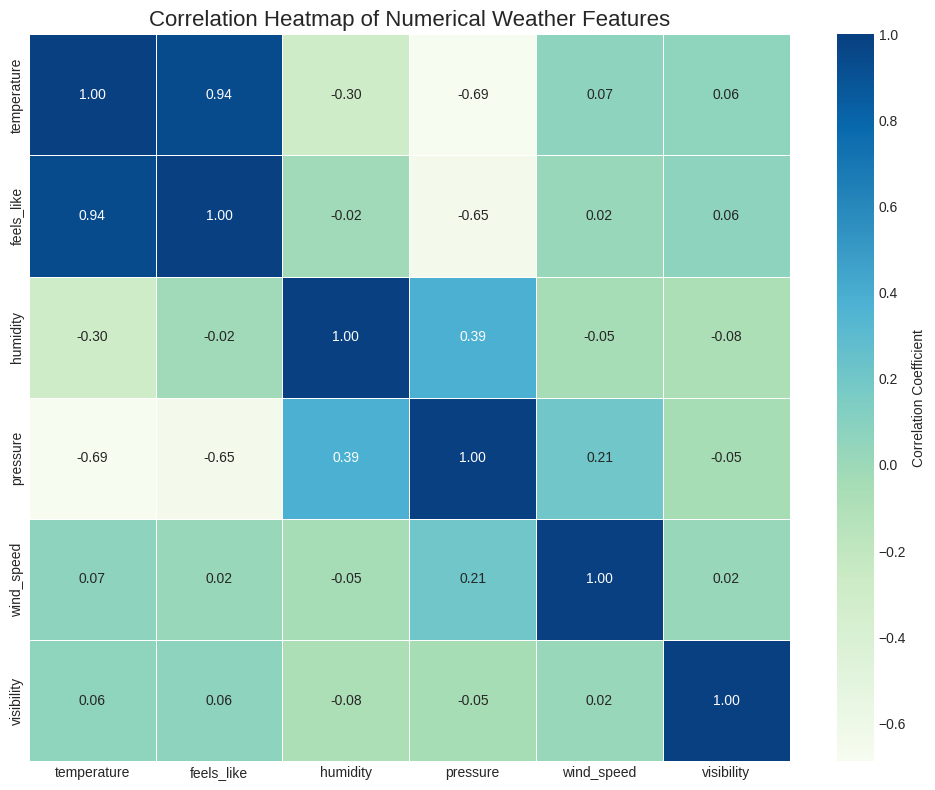

In [26]:
plt.style.use('seaborn-v0_8-whitegrid')
numerical_cols = weather_data_from_db.select_dtypes(include=np.number).columns
correlation_matrix = weather_data_from_db[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu', fmt='.2f', linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'}) # Changed cmap to 'GnBu'
plt.title('Correlation Heatmap of Numerical Weather Features', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Double Line Plot: Temperature vs. Feels Like Temperature

Let's visualize both the actual temperature and the 'feels like' temperature for a selection of cities to see their relationship and any discrepancies.

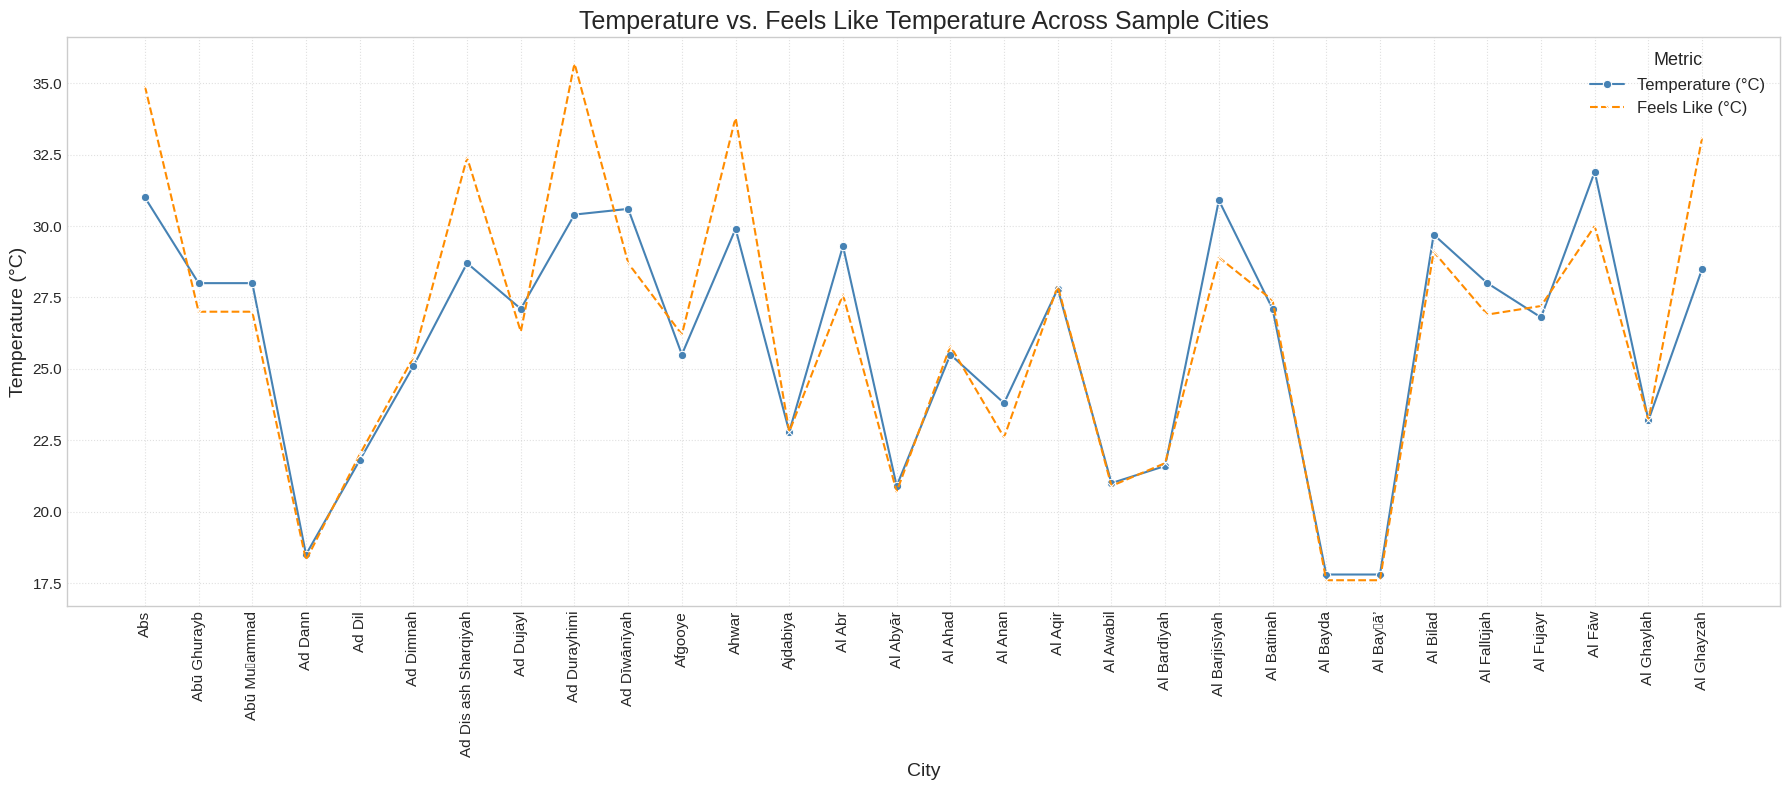

In [27]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(18, 8))

cities_to_plot = weather_data_from_db.sort_values('city').head(30)

sns.lineplot(x='city', y='temperature', data=cities_to_plot, marker='o', linestyle='-', label='Temperature (°C)', color='steelblue')
sns.lineplot(x='city', y='feels_like', data=cities_to_plot, marker='x', linestyle='--', label='Feels Like (°C)', color='darkorange')

plt.title('Temperature vs. Feels Like Temperature Across Sample Cities', fontsize=18)
plt.xlabel('City', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Metric', fontsize=12, title_fontsize='13')
plt.tight_layout()
plt.show()

### Box Plot: Temperature Distribution by Weather Condition

To understand how temperature varies across different weather conditions, a box plot is effective. This will show the median, quartiles, and potential outliers for each condition.

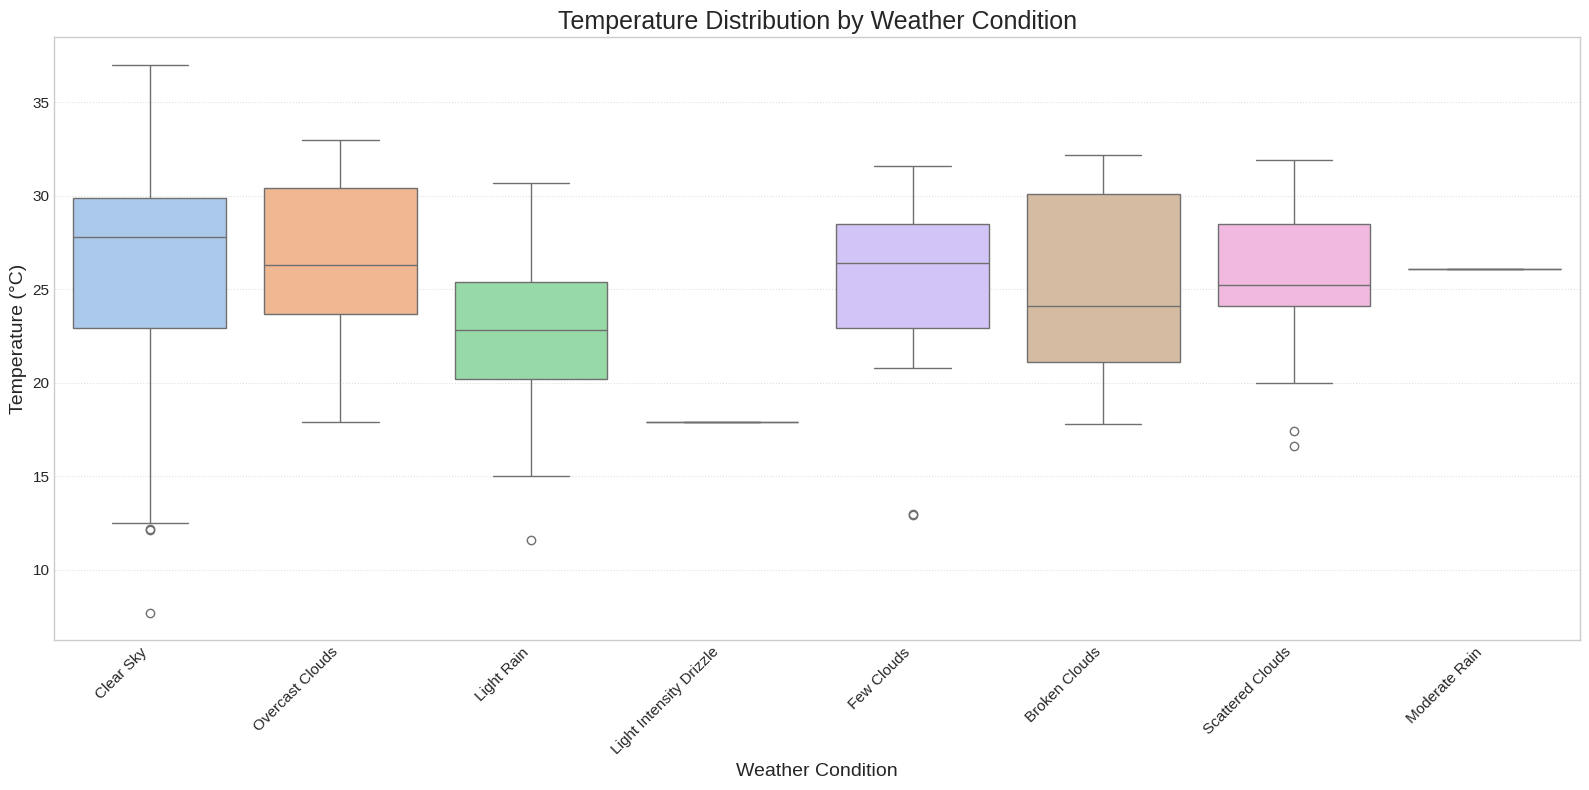

Database connection closed after all plots.


In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 8))
sns.boxplot(x='condition', y='temperature', data=weather_data_from_db, palette='pastel')

plt.title('Temperature Distribution by Weather Condition', fontsize=18)
plt.xlabel('Weather Condition', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Close the database connection after all plots
conn.close()
print("Database connection closed after all plots.")